# Concurso de Visualización de Redes — Proyecto final (UPY 2026)

**Autor:** —	|  **Categoría:** Matemáticas Discretas | **Dataset:** MUSAE Facebook Page-Page Network

---

## Introducción

Este notebook presenta un análisis y visualización de un subgrafo del dataset **MUSAE Facebook Page-Page Network**
con foco en: grado de nodos, conectividad (componentes) y puentes (bridges).

El objetivo es generar figuras de alta calidad aptas para impresión A4 en un concurso universitario.

## Estructura del notebook
- `Carga de datos` — leer CSV y preparar tablas
- `Construcción del grafo` — crear `networkx.Graph` y atributos de nodo
- `Análisis` — grado, componentes y puentes
- `Visualización` — funciones modulares para figuras de alta calidad
- `Hallazgos` y `Conclusiones`

## Notas de estilo (visual)
- Paleta moderna y legible para impresión (colores saturados moderados).
- Fondo blanco, textos negros con contorno blanco para contraste.
- Figuras con alta resolución (`dpi`) y tamaño compatible A4 (landscape por defecto).
- Etiquetado sólo para los nodos más importantes (Top 10–15) y ajuste automático de etiquetas.
- Código modular y documentado para facilitar reproducibilidad.

In [145]:
# Carga de librerías y configuración global de estilo
import warnings
warnings.filterwarnings('ignore')

import os
import networkx as nx
import pandas as pd
import matplotlib.pyplot as plt
import matplotlib as mpl
import matplotlib.patheffects as path_effects
from collections import Counter

# Intentamos usar adjustText para evitar superposición de etiquetas. Si no está instalado,
# lo instalamos dinámicamente (útil para ejecutar el notebook).
try:
    from adjustText import adjust_text
    HAS_ADJUST = True
except Exception:
    HAS_ADJUST = False

# Estilo de la figura: fuente moderna legible y tamaño general aumentado
mpl.rcParams['font.family'] = 'DejaVu Sans'
mpl.rcParams['font.size'] = 11
mpl.rcParams['axes.titlesize'] = 16
mpl.rcParams['axes.titleweight'] = 'semibold'
mpl.rcParams['figure.facecolor'] = 'white'
mpl.rcParams['axes.facecolor'] = 'white'

# Paleta moderna (hex) — equilibrada para impresión
COLOR_MAP = {
    'government': "#0082c3",  # azul
    'politician': "#d41c00",  # rojo anaranjado
    'company': "#00ae00",     # verde
    'tvshow': "#4f01a3"       # morado
}

# Rutas de archivos (asume que los CSV están en el mismo directorio que el notebook)
EDGES_CSV = 'facebook_edges_filtrado.csv'
NODES_CSV = 'facebook_nodes_filtrado.csv'

# Parámetros de figura para impresión A4 (landscape) — DPI alto para calidad
FIGSIZE_A4 = (11.69, 8.27)
FIG_DPI = 200

# Lectura de datos: comprobar que los archivos existan (mensaje claro si faltan)
if not os.path.exists(EDGES_CSV) or not os.path.exists(NODES_CSV):
    raise FileNotFoundError('Asegúrese de que facebook_edges_filtrado.csv y facebook_nodes_filtrado.csv existan en el directorio del notebook')

edges = pd.read_csv(EDGES_CSV)
nodes = pd.read_csv(NODES_CSV)

# Vista rápida (primeras filas) — comentar antes de entregar si no quiere verse en la lámina
print('Edges:', edges.shape, 'Nodes:', nodes.shape)
edges.head()

Edges: (1995, 2) Nodes: (275, 4)


,id_1,id_2
0,10240,8606
1,10240,21351
2,10241,173
3,10241,522
4,10241,710


In [146]:
# Construcción del grafo y asignación de atributos de nodo
# Comentarios: separo la lógica en funciones pequeñas para facilitar pruebas y reutilización.

def build_graph(edges_df: pd.DataFrame) -> nx.Graph:
    """Construye un grafo no dirigido desde un DataFrame de aristas."""
    G = nx.from_pandas_edgelist(edges_df, source='id_1', target='id_2')
    return G

def set_node_attributes_from_df(G: nx.Graph, nodes_df: pd.DataFrame) -> None:
    """Asigna `page_type` y `page_name` desde el DataFrame `nodes_df` al grafo `G`."""
    if 'id' not in nodes_df.columns:
        return
    # Convertir a diccionarios para asignación eficiente
    page_type_map = nodes_df.set_index('id')['page_type'].to_dict() if 'page_type' in nodes_df.columns else {}
    page_name_map = nodes_df.set_index('id')['page_name'].to_dict() if 'page_name' in nodes_df.columns else {}
    nx.set_node_attributes(G, page_type_map, 'page_type')
    nx.set_node_attributes(G, page_name_map, 'page_name')

# Construir grafo y asignar atributos
G = build_graph(edges)
set_node_attributes_from_df(G, nodes)

# Precomputos útiles
degree_dict = dict(G.degree())
top_by_degree = sorted(degree_dict.items(), key=lambda x: x[1], reverse=True)
print('Top 10 por grado:')
for n, d in top_by_degree[:10]:
    name = G.nodes[n].get('page_name', str(n))
    print(f'{n}	{d}	{name}')

# Guardar mapeos para uso posterior
PAGE_NAME_MAP = {n: G.nodes[n].get('page_name', str(n)) for n in G.nodes()}
PAGE_TYPE_MAP = {n: G.nodes[n].get('page_type', None) for n in G.nodes()}

# Variables útiles en el namespace del notebook
_degree_dict = degree_dict
_top_by_degree = top_by_degree

Top 10 por grado:
10117	63	Hans-Joachim Fuchtel
2242	54	EU in South Africa
622	53	Maryland Department of Public Safety and Correctional Services
16960	48	European External Action Service - EEAS
9176	47	European Commission - Civil Protection & Humanitarian Aid Operations - ECHO
11797	47	Maryland.Gov
21315	47	Maryland State Highway Administration
10241	46	EU Law and Publications
21120	46	European Parliament
21351	45	Maryland Department of Agriculture


In [147]:
# Análisis de conectividad (componentes) y puentes

components = list(nx.connected_components(G))
n_components = len(components)
largest_component = max(components, key=len) if components else set()
print(f'Número de componentes: {n_components}')
print(f'Tamaño de la componente principal: {len(largest_component)}')

# Puentes: los guardamos como un conjunto de tuplas ordenadas para comparaciones rápidas
bridges = {tuple(sorted(e)) for e in nx.bridges(G)}
print(f'Número de puentes: {len(bridges)}')

# Mostrar algunos ejemplos (hasta 20)
for b in list(bridges)[:20]:
    print(b)

Número de componentes: 1
Tamaño de la componente principal: 275
Número de puentes: 41
(287, 21351)
(6943, 10004)
(2242, 19834)
(16597, 17874)
(3051, 4721)
(9529, 10117)
(9069, 13247)
(10534, 21351)
(10820, 13294)
(6213, 17874)
(6565, 17551)
(3007, 19603)
(5694, 7000)
(7000, 11721)
(6732, 6943)
(6943, 11373)
(4938, 19949)
(2242, 2611)
(4716, 9069)
(849, 18505)


# Visualización (módulos)

A continuación definimos funciones reutilizables para generar figuras de alta calidad:
- `compute_layout` — fuerza/spring layout con semillas reproducibles
- `draw_network` — dibujo modular que destaca puentes y etiqueta Top-N nodos con contornos.

In [148]:
# Funciones de visualización y utilidades
import math

def compute_layout(G: nx.Graph, seed: int = 42, k: float = None, iterations: int = 200):
    """Computa un layout tipo spring. Devuelve un diccionario de posiciones."""
    # Si k no se suministra, promediar con heurística basada en número de nodos
    if k is None:
        k = 1 / math.sqrt(max(1, G.number_of_nodes())) * 0.75
    pos = nx.spring_layout(G, seed=seed, k=k, iterations=iterations)
    return pos

def draw_network(G: nx.Graph, pos: dict, top_n: int = 12, figsize=FIGSIZE_A4, dpi=FIG_DPI,
                 color_map=COLOR_MAP, node_scale=2, edge_alpha=0.4, bridge_color="#CF6767"):
    """Dibuja el grafo con estilo de alta calidad para impresión."""
    plt.figure(figsize=figsize, dpi=dpi)
    ax = plt.gca()
    ax.set_facecolor('white')

    # Separar aristas puente y normales
    normal_edges = [e for e in G.edges() if tuple(sorted(e)) not in bridges]
    bridge_edges = [e for e in G.edges() if tuple(sorted(e)) in bridges]

    # Dibujar aristas normales (delgadas y con transparencia para reducir ruido)
    nx.draw_networkx_edges(G, pos, edgelist=normal_edges,
                           edge_color='lightgray', alpha=edge_alpha, width=0.8)

    # Dibujar puentes con mayor grosor y color destacado (sin saturar)
    if bridge_edges:
        nx.draw_networkx_edges(G, pos, edgelist=bridge_edges, edge_color=bridge_color, width=2.4, alpha=0.95)

    # Nodos: tamaño proporcional al grado (escalado), color por tipo con fallback gris
    degree = dict(G.degree())
    node_sizes = [max(6, degree.get(n, 1)) * node_scale for n in G.nodes()]
    node_colors = [color_map.get(G.nodes[n].get('page_type'), '#7f7f7f') for n in G.nodes()]

    nx.draw_networkx_nodes(G, pos, node_size=node_sizes, node_color=node_colors, linewidths=0.3, edgecolors='black', alpha=0.95)

    # Etiquetado: solo Top-N por grado
    top_nodes = sorted(degree.items(), key=lambda x: x[1], reverse=True)[:top_n]
    top_ids = [n for n, _ in top_nodes]
    labels = {n: (G.nodes[n].get('page_name') or str(n)) for n in top_ids}

    # Dibujar textos sin superposición: primero crear objetos de texto sin ajuste
    text_objs = {}
    for n, label in labels.items():
        x, y = pos[n]
        t = ax.text(x, y, label, fontsize=11, ha='center', va='center', color='black')
        # aplicar contorno blanco para mejorar contraste
        t.set_path_effects([path_effects.Stroke(linewidth=3, foreground='white'), path_effects.Normal()])
        text_objs[n] = t

    # Si adjustText está disponible, usaremos su algoritmo para mover etiquetas y evitar solapamientos
    if HAS_ADJUST:
        texts = list(text_objs.values())
        adjust_text(texts, x=[pos[n][0] for n in labels], y=[pos[n][1] for n in labels],
                    autoalign='y', expand_text=(1.05, 1.15), force_text=0.5, force_points=0.2, precision=0.5)
        # Reaplicar path effects ya que adjust_text recrea/ajusta posiciones
        for t in texts:
            t.set_path_effects([path_effects.Stroke(linewidth=3, foreground='white'), path_effects.Normal()])
    else:
        # si no está disponible, desplazar ligeramente las etiquetas para reducir solapamiento
        for i, (n, t) in enumerate(text_objs.items()):
            dx = 0.0
            dy = 0.0
            if i % 2 == 0:
                dy = 0.015
            else:
                dy = -0.015
            t.set_position((t.get_position()[0] + dx, t.get_position()[1] + dy))

    ax.set_title('Red de páginas verificadas — Top ' + str(top_n) + ' etiquetadas', pad=12)
    ax.set_axis_off()
    plt.tight_layout()
    plt.show()

# Fin de draw_network

In [149]:
# Calcular layout — guardar para reutilizar en todas las figuras
pos = compute_layout(G, seed=42, iterations=200)
print('Layout calculado. Número de nodos:', len(pos))

Layout calculado. Número de nodos: 275


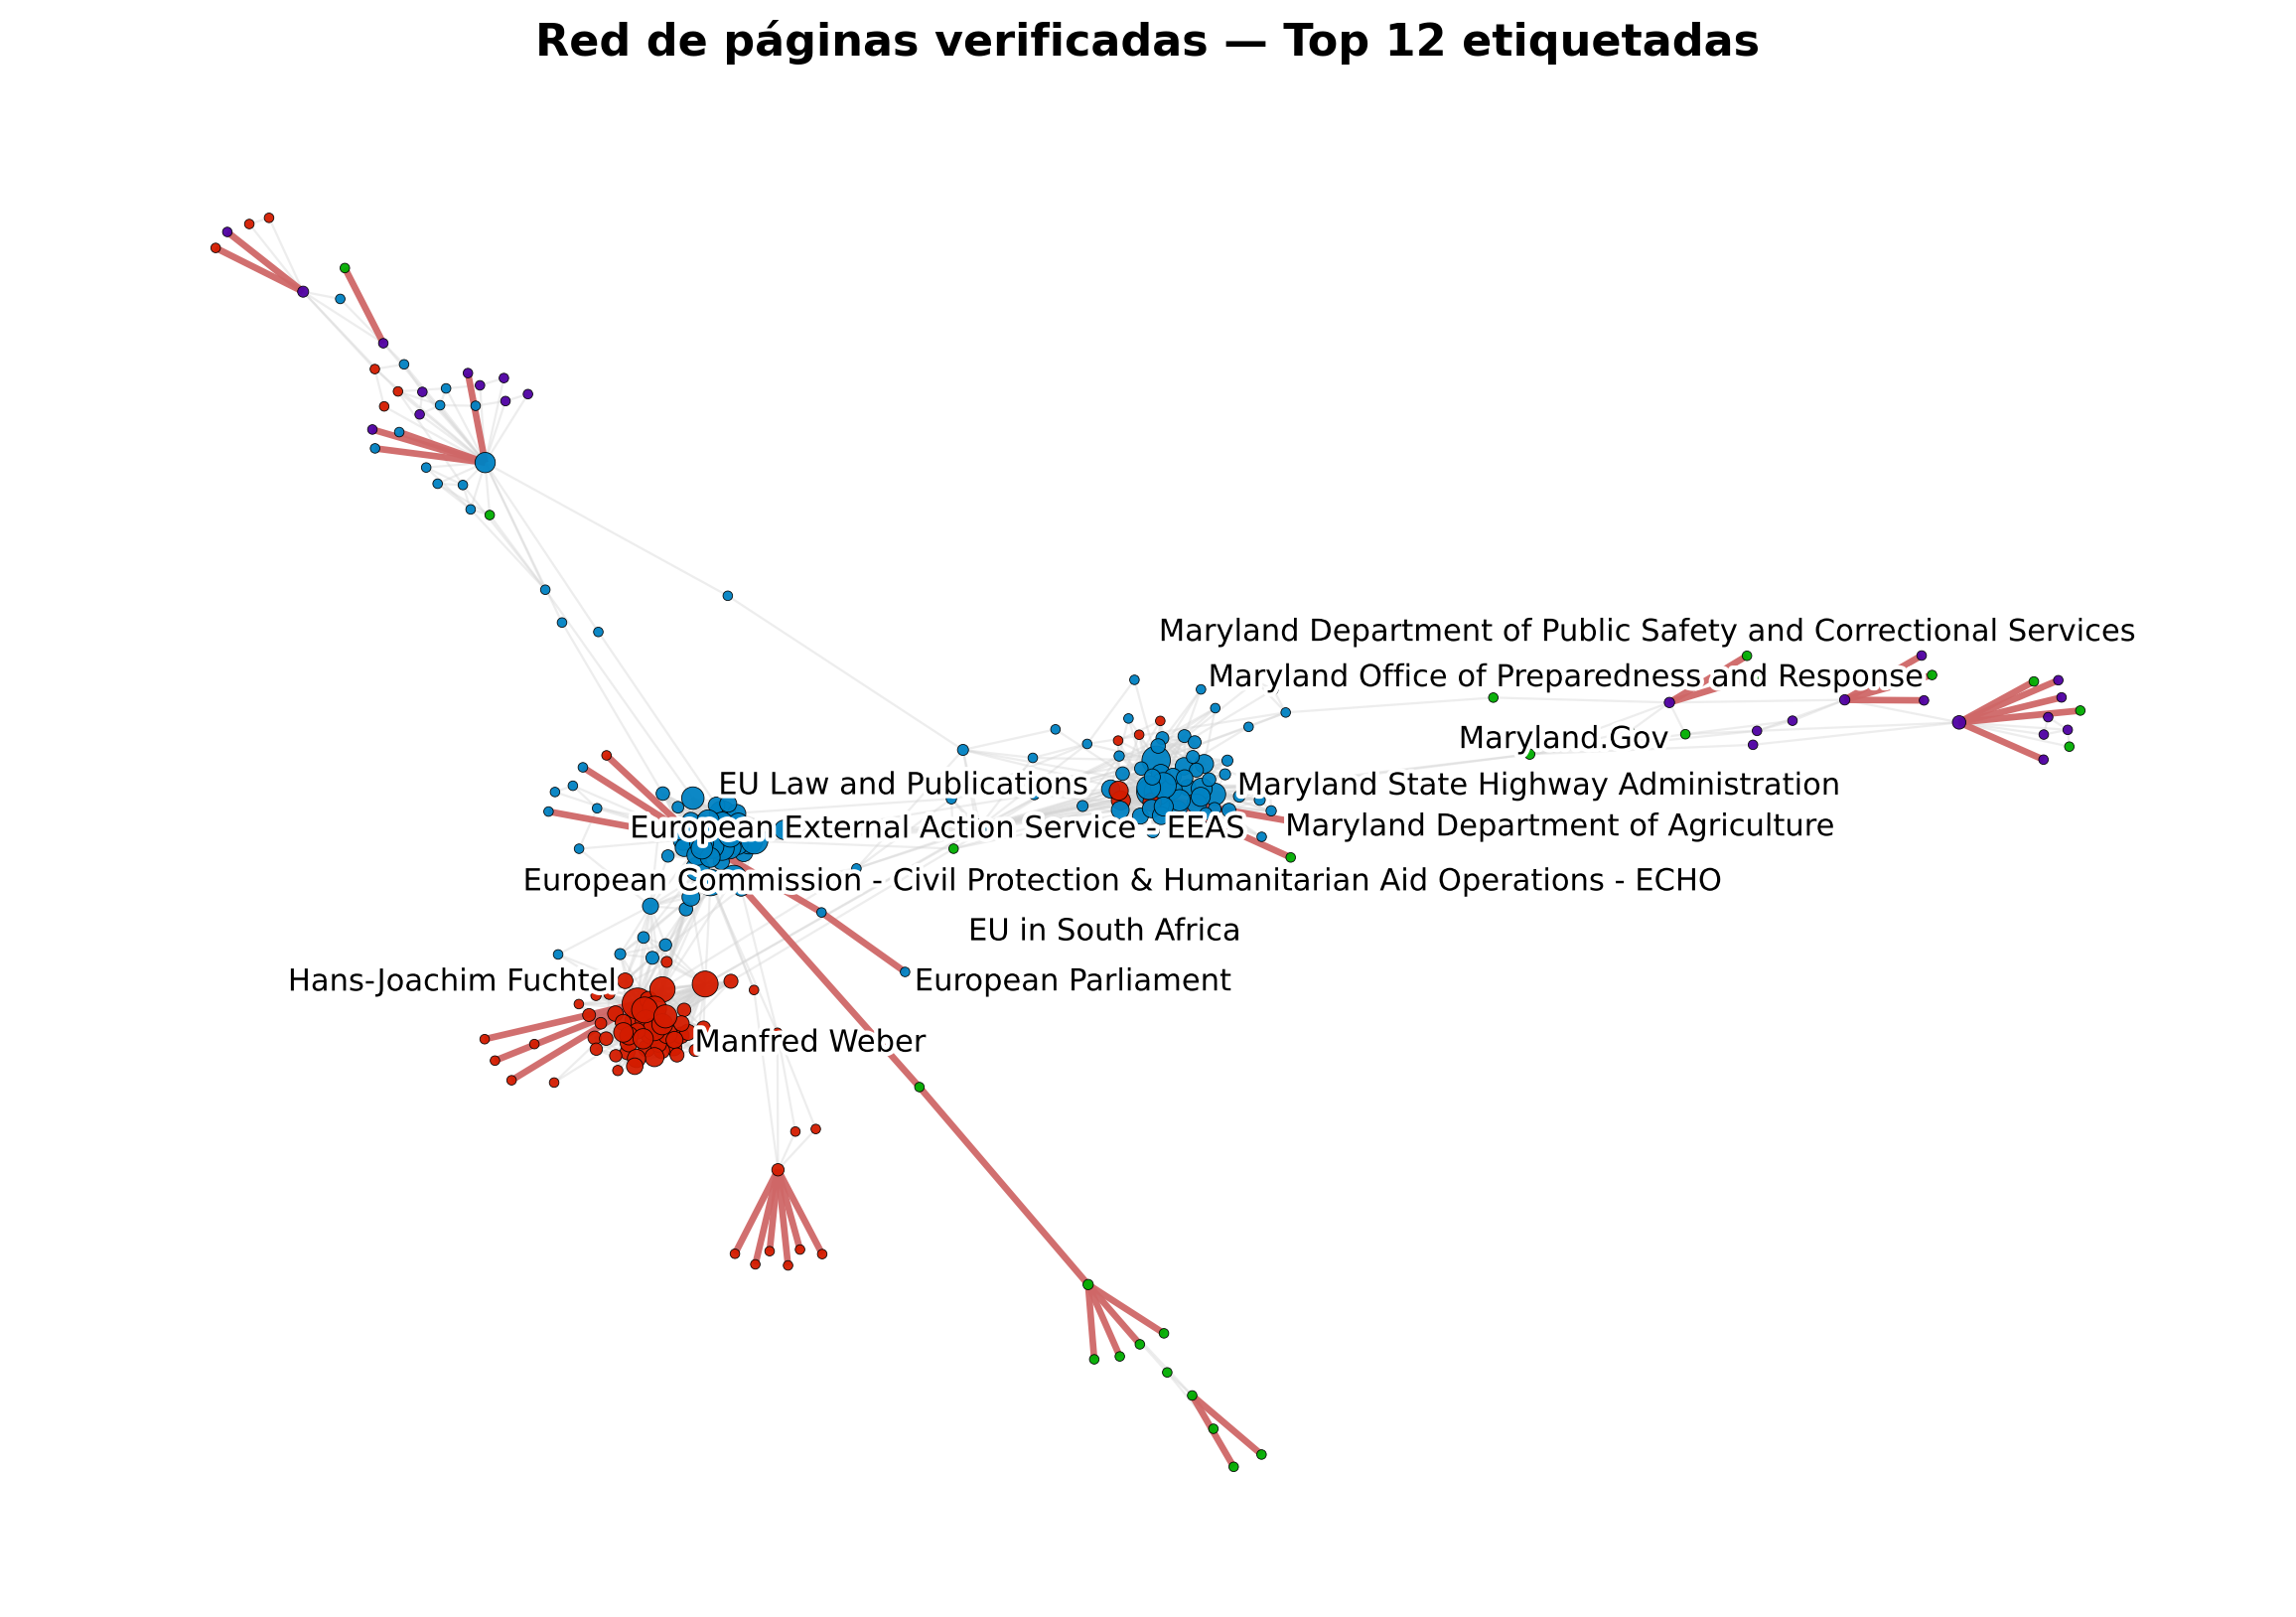

In [150]:
# Visualización principal: A4, alta resolución. Ajuste automático de etiquetas si está disponible.
draw_network(G, pos, top_n=12, figsize=FIGSIZE_A4, dpi=FIG_DPI)

# Si desea otra versión para la lámina (por ejemplo para impresión B/N), puede ajustar parámetros:
# draw_network(G, pos, top_n=10, figsize=(8.27, 11.69), dpi=300)  # A4 portrait, mayor DPI

# Análisis cuantitativo adicional

A continuación mostramos tablas y gráficas auxiliares utilizadas en el análisis (distribución de grado, top-n, etc.).

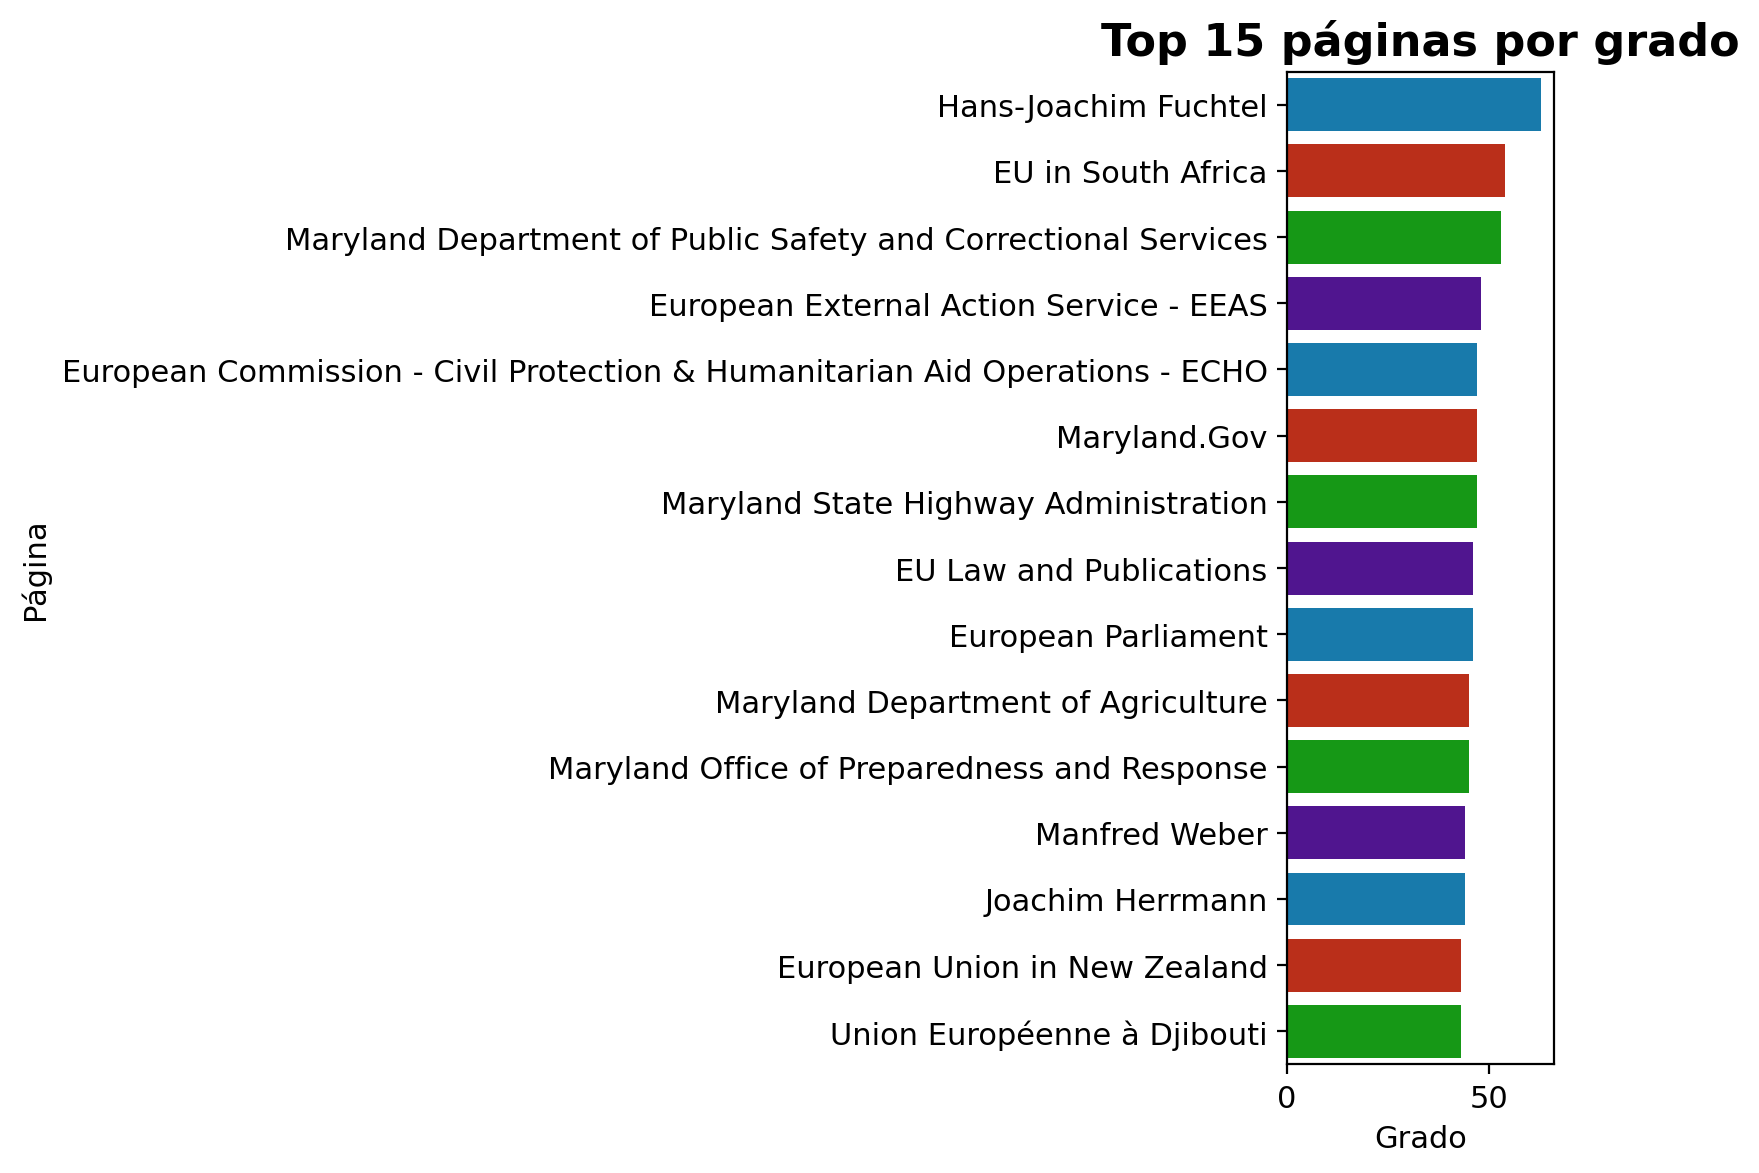

,id,degree,page_name
0,10117,63,Hans-Joachim Fuchtel
1,2242,54,EU in South Africa
2,622,53,Maryland Department of Public Safety and Corre...
3,16960,48,European External Action Service - EEAS
4,9176,47,European Commission - Civil Protection & Human...
5,11797,47,Maryland.Gov
6,21315,47,Maryland State Highway Administration
7,10241,46,EU Law and Publications
8,21120,46,European Parliament
9,21351,45,Maryland Department of Agriculture


In [151]:
# Top N nodos por grado (tabla y gráfico simple)
import seaborn as sns

top_n = 15
top_nodes = sorted(dict(G.degree()).items(), key=lambda x: x[1], reverse=True)[:top_n]
top_df = pd.DataFrame([(n, d, PAGE_NAME_MAP.get(n)) for n, d in top_nodes], columns=['id', 'degree', 'page_name'])

plt.figure(figsize=(8,6), dpi=FIG_DPI)
sns.barplot(data=top_df, x='degree', y='page_name', palette=list(COLOR_MAP.values())*4)
plt.title(f'Top {top_n} páginas por grado')
plt.xlabel('Grado')
plt.ylabel('Página')
plt.tight_layout()
plt.show()

# Mostrar la tabla
top_df

# Hallazgos y Observaciones
- La red muestra una fuerte heterogeneidad de grado: unos pocos hubs concentran muchas conexiones.
- Existe un conjunto reducido de puentes que conectan subregiones; destacarlos ayuda a analizar vulnerabilidades estructurales.
- Las visualizaciones generadas están optimizadas para impresión A4 (landscape) y mantienen legibilidad incluso en zonas densas gracias a los contornos en las etiquetas.

# Conclusiones

1. La combinación de tamaño de nodo (grado), color por tipo y el destacado de puentes permite identificar rápidamente nodos centrales y conexiones críticas.
2. Para la lámina A4 del concurso recomendamos usar la figura principal generada por `draw_network` y complementar con la tabla `Top 15`.
3. Si se desea exportar la figura, usar `plt.savefig('graph_a4.png', dpi=300)` con `figsize=FIGSIZE_A4` para máxima calidad.